## Empty wave flume single domain - Frequency-Domain Boundary Element Method (BEM)

**3D Boundary Element Method for Linear Wave Propagation**

This tutorial presents the implementation of a 3D Boundary Element Method (BEM) to simulate the propagation of regular linear water waves in an empty wave flume.

The formulation is based on:
- Linear potential flow theory  
- Frequency-domain (time-harmonic) analysis  
- Boundary integral equation formulation  

Objectives of this notebook:
- Introduce the workflow and structure of the code  
- Solve the wave propagation problem in a simple domain
- Compute wave reflection and transmission coefficients
- Analyse the effect of mesh refinement on the coefficients 

**1. Environment setup**

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from BEM_UTILS.constants import gravity, rho

from BEM_UTILS_LIN.PROCESS_MESH_LINEAR import PROCESS_MESH_LINEAR

from BEM_UTILS_CONS.PROCESS_CONNECTIVITY_CONSTANT import PROCESS_CONNECTIVITY_CONSTANT
from BEM_UTILS_CONS.ENERGY_FLUX_CONSTANT import ENERGY_FLUX_CONSTANT
from BEM_UTILS_CONS.AREA_QUADS import AREA_QUADS

from BEM_UTILS_LIN.IDENTIFY_BOUNDARY_ELEMENTS_LINEAR import IDENTIFY_BOUNDARY_ELEMENTS_LINEAR
from BEM_UTILS_LIN.COS_DIR_LINEAR import COS_DIR_LINEAR

from MATRICES_CONS.GHMAT5 import GHMAT5
from MATRICES_CONS.EXTIN5 import EXTIN5
from MATRICES_CONS.LOCIN5 import LOCIN5
from MATRICES_CONS.FUNDA5 import FUNDA5

from BOUNDARY_CONDITIONS_CONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS_CONS.BC_FAR_FIELD_IN import BC_FAR_FIELD_IN
from BOUNDARY_CONDITIONS_CONS.BC_FAR_FIELD_OUT import BC_FAR_FIELD_OUT
from BOUNDARY_CONDITIONS_CONS.BC_SCATTERING import BC_SCATTERING

from BEM_UTILS_CONS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

**2.1 Physical domain and geometry parameters**

In [2]:
# Fluid domain
DEPTH = 0.40            # [m]
WIDTH_CHANNEL = 0.10 * DEPTH

# Numerical model
NUM_OF_REG = 1

# Structure geometry
N_STRUCT = 0;

**2.2 Wave parameters and frequency range**

In [3]:
# Number of frequencies / wave cases
ttmax = 15

# Dimensionless wavenumber (k*h)
kh = np.linspace(0.005, 3.00, ttmax)   

# Wave steepness H/λ
HL = 0.01                     

**3. Mesh**

In [4]:
# Read the Gmsh file and extract node coordinates and element connectivity
MESH_0_POS, MESH_0_QUADS4 = PROCESS_MESH_LINEAR("DOMAIN_EMPTY_LINEAR.msh")

In [5]:
# Quadrilateral elements are used; each constant element has 4 vertices ordered counterclockwise.
NCONEC = 4;

In [6]:
# Initialize arrays to store the number of nodes (N) and elements (NE) per region
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [7]:
# Extract the number of nodes, number of elements, re order element connectivity and centroid
N[0] ,  NE[0] , KCONEC_0 , MESH_0_POS_C = PROCESS_CONNECTIVITY_CONSTANT(MESH_0_POS , MESH_0_QUADS4)

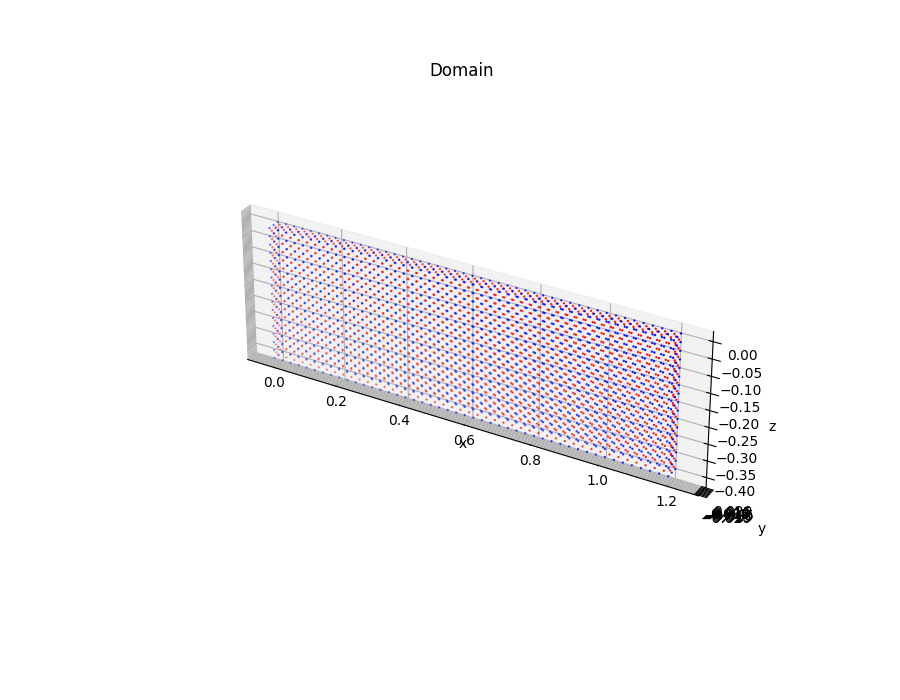

In [8]:
# Domain visulization
%matplotlib widget

fig = plt.figure(figsize=(9, 7)) # Interactive plots also respect figsize
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='b',
    s=0.5
)

ax.scatter(
    MESH_0_POS_C[:,0],
    MESH_0_POS_C[:,1],
    MESH_0_POS_C[:,2],
    c='r',
    s=0.5
)

# DOMAIN LIMITS
x_min, x_max = np.min(MESH_0_POS[:,0]), np.max(MESH_0_POS[:,0])
y_min, y_max = np.min(MESH_0_POS[:,1]), np.max(MESH_0_POS[:,1])
z_min, z_max = np.min(MESH_0_POS[:,2]), np.max(MESH_0_POS[:,2])

Lx = x_max - x_min
Ly = y_max - y_min
Lz = z_max - z_min

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Domain")

# Aspect ratio
ax.set_box_aspect([Lx, Ly, Lz])

plt.show()

In [9]:
# Identify elements belonging to each boundary and compute their outward normal vectors
REF_R0 , NORMAL_0 = IDENTIFY_BOUNDARY_ELEMENTS_LINEAR(NCONEC , KCONEC_0 , MESH_0_POS , NE[0], N_STRUCT)

In [10]:
# Area of each element (flat surfaces)
AREA_ELEM = AREA_QUADS(KCONEC_0, MESH_0_POS, NE[0])

**4. Influence matrices**

In [11]:
# Form H and B matrices
H , G = GHMAT5(MESH_0_POS , MESH_0_POS_C , KCONEC_0 , NE[0] , DEPTH)

**5. Frequency loop and boundary condition application**

In [12]:
# Preallocate arrays for reflection/transmission coefficients
CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

# Dictionary to store wave properties for each frequency case
WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# Frequency loop
for tt in range(ttmax):

    print(tt + 1)

    # Compute wavenumber from dimensionless kh
    k = kh[tt] / DEPTH

    # Linear wave dispersion relation → wave period
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # Wave frequency and angular frequency
    f = 1.0 / T
    omega = 2*np.pi*f

    # Wave height from steepness H/λ and corresponding amplitude
    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # Backup original system matrices before applying BCs
    A = H.copy()
    B = G.copy()

    # ------------------------
    # Apply boundary conditions
    # ------------------------

    # Free-surface boundary condition
    A = BC_FREE_SURFACE(A, B, omega, gravity, REF_R0["FS"], NE, 0)

    # Radiation boundary conditions at inlet and outlet (far field)
    A = BC_FAR_FIELD_IN( A, B, k, NORMAL_0, REF_R0["IN"],  NE, 0)
    A = BC_FAR_FIELD_OUT(A, B, k, NORMAL_0, REF_R0["OUT"], NE, 0)

    # Scattering boundary condition from incident potential at inlet
    BC_S = np.zeros(NE[0], dtype=np.complex128)
    BC_S = BC_SCATTERING(BC_S, Wave_height, k, omega, gravity, DEPTH, MESH_0_POS_C, REF_R0["IN"], N, NE, 0)

    # Build right-hand-side vector (B · BC_S)
    FX_S = np.matmul(B, BC_S)

    # Solve linear BEM system
    Coef_S = np.linalg.solve(A, FX_S)

    # Incident wave energy flux
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    # Compute reflected and transmitted energy fluxes
    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX_CONSTANT(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, AREA_ELEM,
        REF_R0["IN"],  MESH_0_POS_C,
        REF_R0["OUT"], MESH_0_POS_C,
        N, NE, 0, 0)
    
    # Reflection and transmission coefficients (amplitude-based)
    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    # Reflection, transmission and dissipation coefficients (energy-based)
    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]

# End of frequency loop

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


**6. Results**

**6.1 Energy coefficients**

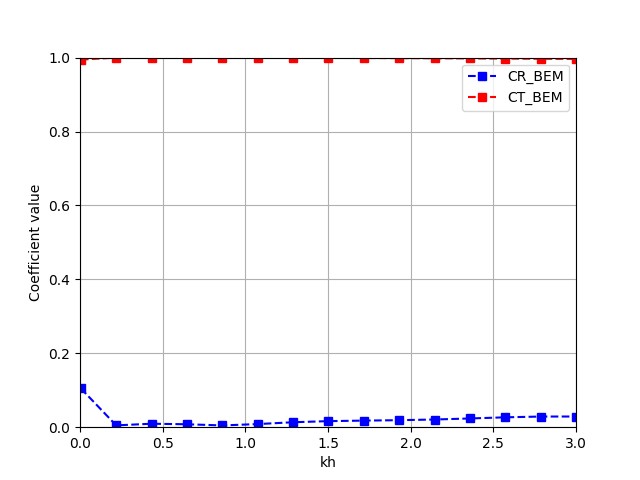

CR = [0.1050287  0.00493882 0.00938442 0.00792533 0.00477241 0.00843282
 0.0134079  0.01640271 0.01784496 0.0189781  0.02081347 0.02362511
 0.02673438 0.02881676 0.0289003 ]
CT = [0.99446882 0.99997848 0.99991859 0.99987858 0.99981379 0.99966534
 0.99944248 0.99918369 0.99890089 0.9985818  0.99821162 0.99778424
 0.99731207 0.99683128 0.99637621]


In [13]:
# Plot of the CR and CT vs kh
plt.figure()

plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CT_BEM')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

plt.show()

print("CR =",CR)
print("CT =",CT)

**6.2 Free surface**

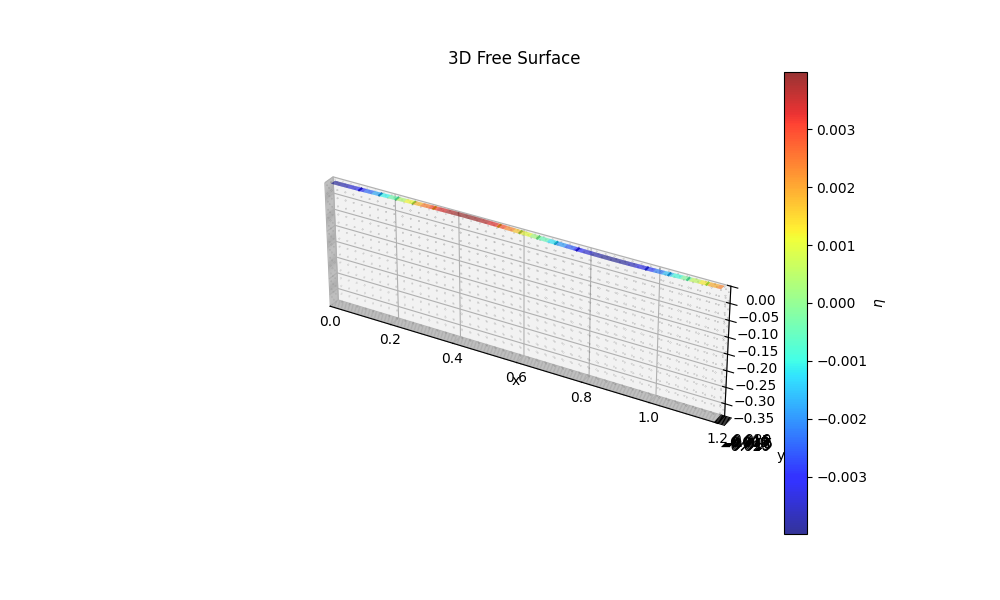

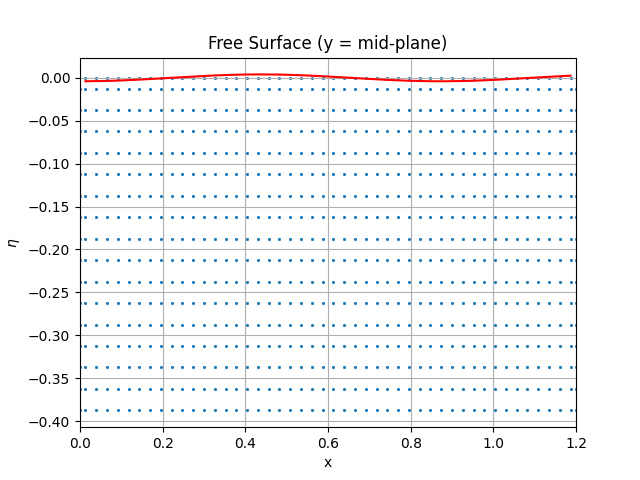

In [16]:
# Free surface plot
PHI_FS_0 = VISUAL_FREE_SURFACE(Coef_S, k, omega, gravity, Wave_height, DEPTH, REF_R0["FS"], MESH_0_POS_C, MESH_0_POS_C, N, NE, 0)